# Finite-Size Spectra of the SSH Lattice
## Numerical Evidence for Bulk–Boundary Correspondence

In this notebook, we analyze the energy spectrum of a finite SSH
lattice in order to examine how the bulk topological classification
identified previously manifests in systems with open boundaries.


## Motivation

While bulk invariants characterize infinite periodic systems,
physically observable consequences of topology emerge only in
finite lattices. In particular, nontrivial bulk topology is
expected to give rise to edge-localized eigenstates when open
boundary conditions are imposed.

Here, we numerically diagonalize finite SSH chains to investigate
the correspondence between bulk topology and boundary modes.

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

In [2]:
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

CONFIG_DIR = Path("..") / "config"

global_config = load_yaml(CONFIG_DIR / "global_config.yaml")
lattice_config = load_yaml(CONFIG_DIR / "lattice_params.yaml")
plotting_config = load_yaml(CONFIG_DIR / "plotting_params.yaml")

NOTEBOOK_KEY = "03_numerical_bandstructures"
assert NOTEBOOK_KEY in plotting_config["notebook_figures"]


## Bloch Bandstructure

We compute the complex Bloch eigenvalues:
- Real part → band dispersion
- Imaginary part → gain/loss rates

In [3]:
def bloch_ssh_hamiltonian(k, t1, t2, gamma_a, gamma_b):
    """
    Bloch Hamiltonian for non-Hermitian SSH model
    with gain (gamma_a) and loss (gamma_b).

    Parameters
    ----------
    k : float
        Crystal momentum
    t1 : float
        Intra-cell hopping
    t2 : float
        Inter-cell hopping
    gamma_a : float
        Gain on A sublattice
    gamma_b : float
        Loss on B sublattice
    """

    offdiag = t1 + t2 * np.exp(-1j * k)

    return np.array(
        [
            [1j * gamma_a,        offdiag],
            [np.conj(offdiag),  -1j * gamma_b]
        ],
        dtype=np.complex128
    )


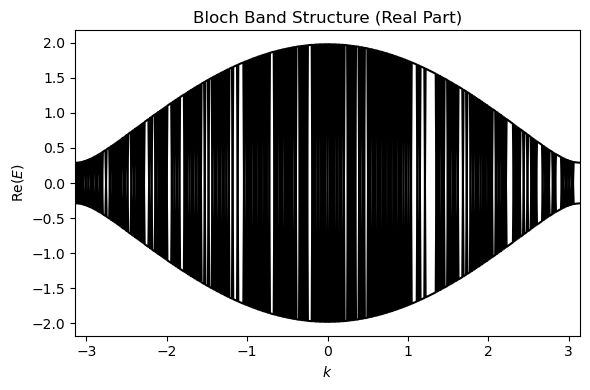

PosixPath('figures/03_numerical_bandstructures/bloch_bands.png')

In [4]:
def ensure_directory(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def save_figure(fig, notebook_key, filename, plotting_config):
    cfg = plotting_config["notebook_figures"][notebook_key]
    output_dir = Path(cfg["output_dir"])
    ensure_directory(output_dir)
    path = output_dir / f"{filename}.{plotting_config['global']['figure_format']}"
    fig.savefig(path, dpi=plotting_config["global"]["dpi"], bbox_inches="tight")
    return path


# Parameters from YAML
t1 = lattice_config["couplings"]["intra_cell"]
t2 = lattice_config["couplings"]["inter_cell"]

gamma_a = lattice_config["non_hermiticity"]["gain"]["strength"]
gamma_b = lattice_config["non_hermiticity"]["loss"]["strength"]


# k-space
k_vals = np.linspace(-np.pi, np.pi, 400)
bands = []

for k in k_vals:
    evals = la.eigvals(
        bloch_ssh_hamiltonian(k, t1, t2, gamma_a, gamma_b)
    )
    bands.append(evals)

bands = np.array(bands)


# Plot
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(k_vals, bands.real[:, 0], color="black")
ax.plot(k_vals, bands.real[:, 1], color="black")

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$\mathrm{Re}(E)$")
ax.set_title("Bloch Band Structure (Real Part)")
ax.set_xlim(-np.pi, np.pi)

plt.tight_layout()
fig_path = save_figure(fig, NOTEBOOK_KEY, "bloch_bands", plotting_config)
plt.show()

fig_path

## Bulk–Edge Correspondence

Edge-localized states appear inside the bulk gap
predicted by the Bloch bandstructure.

The real-energy spectrum of the finite lattice is shown as a function of
eigenstate index, with color indicating edge localization weight. The spectrum
exhibits two bulk bands separated by a gap, while states with enhanced edge
localization appear near the band edges and within the gap. Since the imaginary
parts of the eigenvalues are negligible in this regime, only the real spectrum is
displayed. The presence of edge-localized states provides numerical evidence of
bulk–boundary correspondence in the finite non-Hermitian SSH lattice.
